Starting Monte Carlo Option Pricing Simulation...
------------------------------------------------------------

Select an option:
1. Run Comprehensive Example (Full Demo)
2. Enhanced GBM Visualization
3. Quick GBM Demo (Simple)
4. Monte Carlo Performance Test
5. Exit

Enter your choice (1-5): 1
MONTE CARLO OPTION PRICING SIMULATION

Parameters:
  S0 = $100.00
  K = $105.00
  T = 1.0 years
  r = 5.0%
  σ = 20.0%

EUROPEAN CALL OPTION
Monte Carlo Price: $8.0655
Black-Scholes Price: $8.0214
Difference: $0.0442
95% Confidence Interval: [$7.9433, $8.1878]
Standard Error: $0.0624
Simulation Time: 0.81 seconds

EUROPEAN PUT OPTION
Monte Carlo Price: $7.8866
Black-Scholes Price: $7.9004
Difference: $0.0138

ASIAN (AVERAGE PRICE) CALL OPTION
Arithmetic Asian Call Price: $3.5232
95% Confidence Interval: [$3.4636, $3.5828]

BARRIER OPTION (Up-and-Out Call)
Up-and-Out Barrier Call Price: $0.5877
Barrier Level: $120.00
Knock-out Rate: 88.45%

CONVERGENCE ANALYSIS

Convergence with increasing paths:

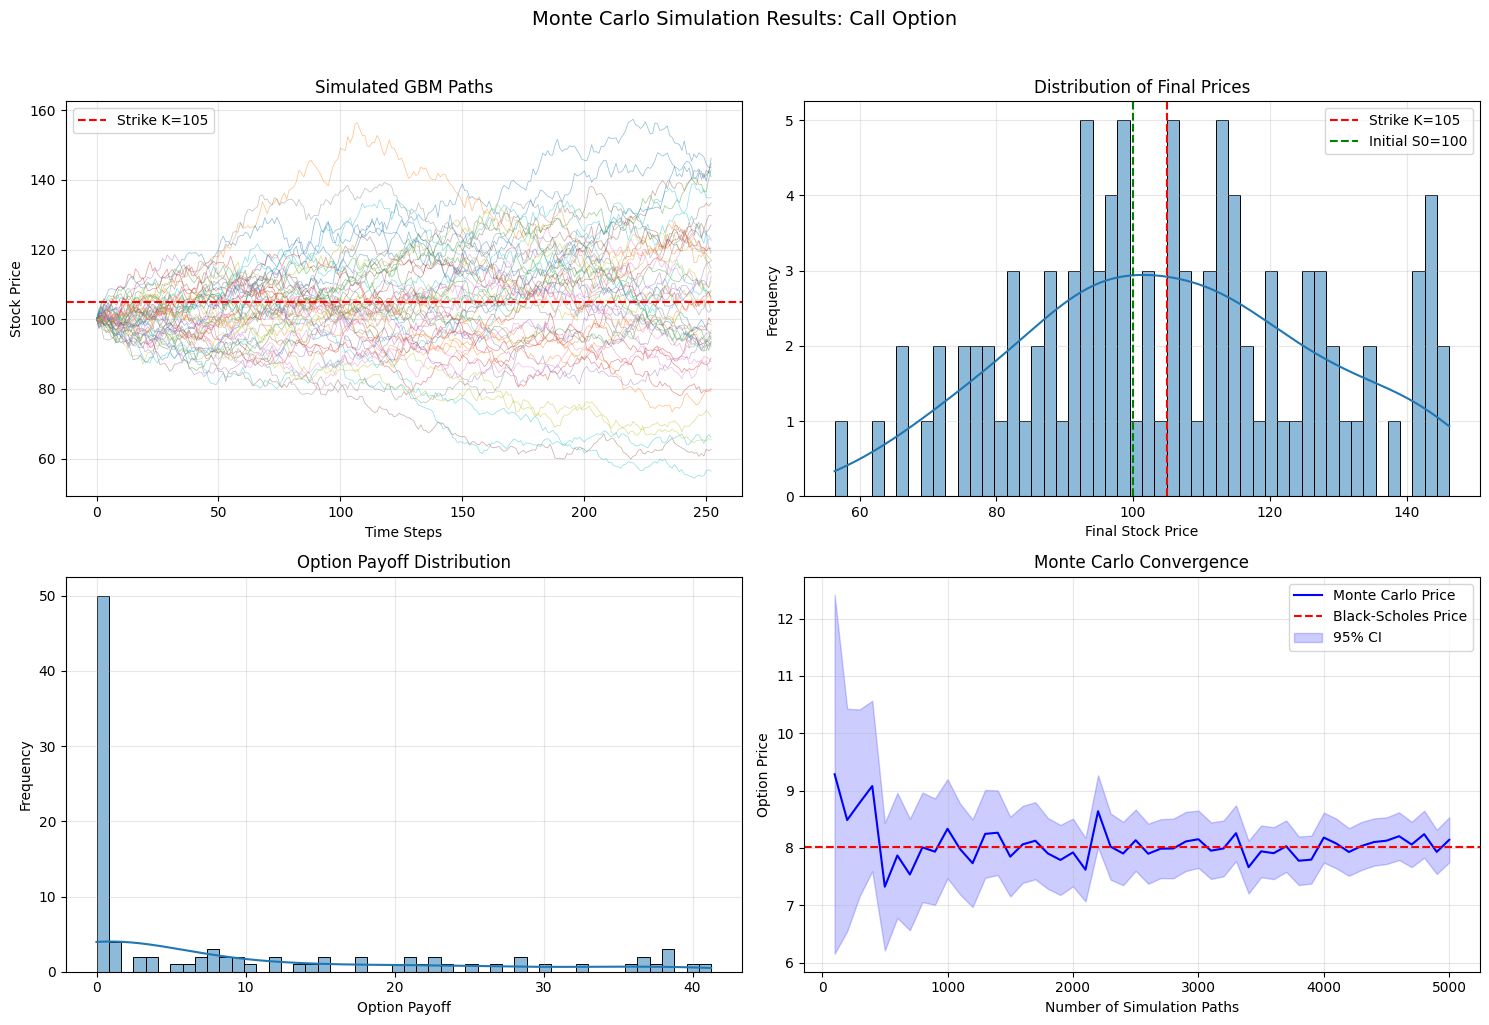


EXAMPLE: PRINCIPAL-PROTECTED NOTE (Hull Example 11.1)

Principal: $1000
Zero-coupon bond price: $835.27
Funds available for option: $164.73
ATM Call option price (MC): $166.22
✗ Structure is NOT PROFITABLE (Option cost $166.22 > Available $164.73)

Select an option:
1. Run Comprehensive Example (Full Demo)
2. Enhanced GBM Visualization
3. Quick GBM Demo (Simple)
4. Monte Carlo Performance Test
5. Exit

Enter your choice (1-5): 2


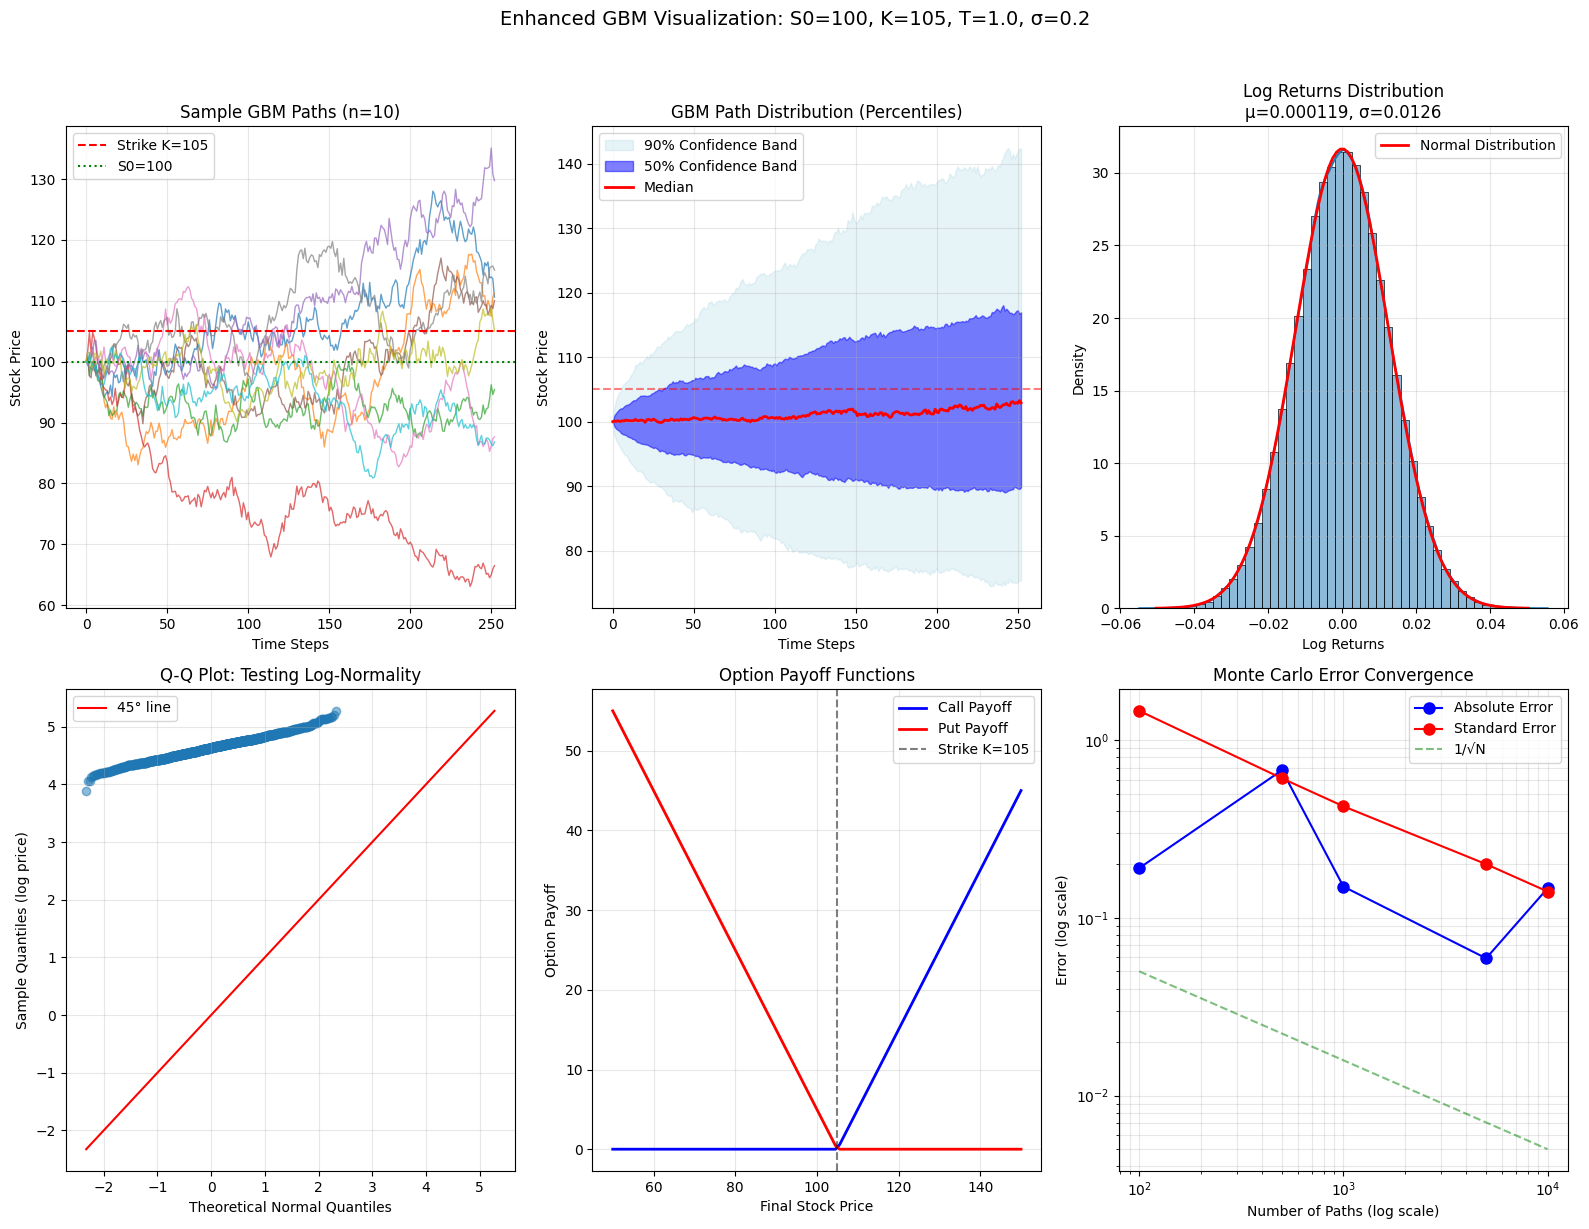


Select an option:
1. Run Comprehensive Example (Full Demo)
2. Enhanced GBM Visualization
3. Quick GBM Demo (Simple)
4. Monte Carlo Performance Test
5. Exit

Enter your choice (1-5): 3


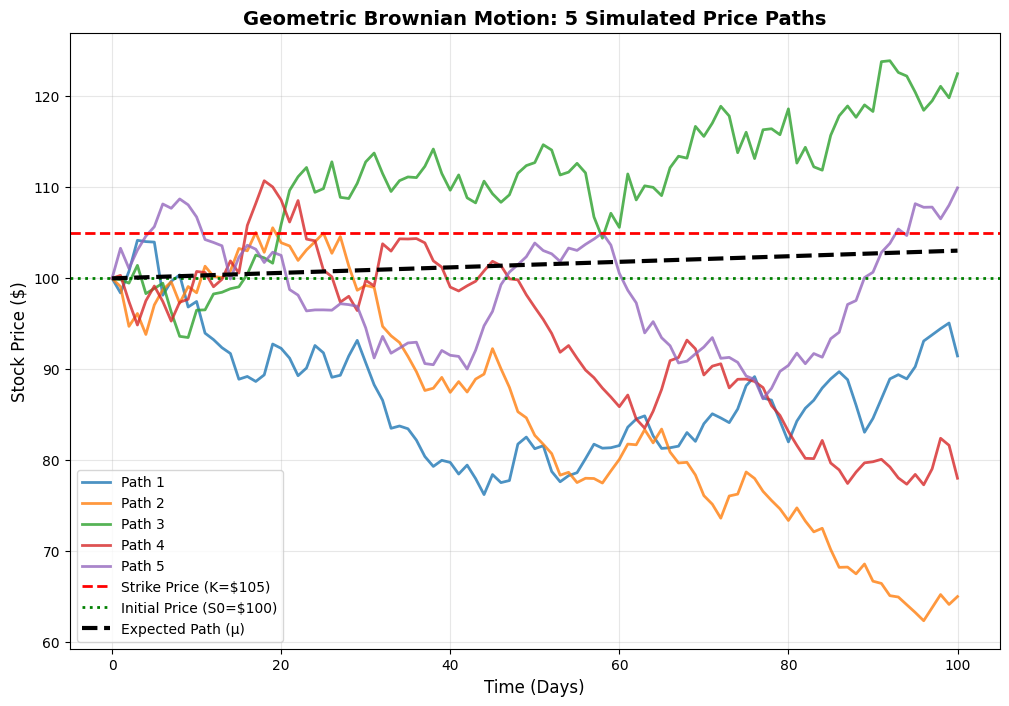


Statistics for 5 simulated paths:
Average final price: $93.39
Standard deviation: $20.81
Maximum final price: $122.49
Minimum final price: $65.03

Call option payoffs at expiration:
  Path 1: Final price = $91.47, Payoff = $0.00
  Path 2: Final price = $65.03, Payoff = $0.00
  Path 3: Final price = $122.49, Payoff = $17.49
  Path 4: Final price = $78.03, Payoff = $0.00
  Path 5: Final price = $109.94, Payoff = $4.94

Estimated option price (discounted average): $4.2682

Select an option:
1. Run Comprehensive Example (Full Demo)
2. Enhanced GBM Visualization
3. Quick GBM Demo (Simple)
4. Monte Carlo Performance Test
5. Exit

Enter your choice (1-5): 4

MONTE CARLO PERFORMANCE TEST

Performance Results:
 n_paths  mc_price    error  std_error  time_sec  paths_per_sec
    1000  8.653633 0.632280   0.454280  0.012305   81264.487629
    5000  8.162613 0.141260   0.199740  0.053830   92885.577869
   10000  7.826772 0.194580   0.135692  0.132280   75597.154408
   50000  8.003798 0.017554   0.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import norm
from typing import Tuple, List, Optional
import time
import seaborn as sns

class MonteCarloOptionPricer:
    """
    A comprehensive Monte Carlo simulation class for pricing various types of options
    """

    def __init__(self, S0: float, K: float, T: float, r: float, sigma: float,
                 option_type: str = 'call', dividend_yield: float = 0.0):
        """
        Initialize option parameters

        Parameters:
        -----------
        S0: Initial stock price
        K: Strike price
        T: Time to maturity (in years)
        r: Risk-free interest rate
        sigma: Volatility
        option_type: 'call' or 'put'
        dividend_yield: Continuous dividend yield
        """
        self.S0 = S0
        self.K = K
        self.T = T
        self.r = r
        self.sigma = sigma
        self.option_type = option_type.lower()
        self.q = dividend_yield

        if self.option_type not in ['call', 'put']:
            raise ValueError("option_type must be 'call' or 'put'")

    def generate_gbm_paths(self, n_paths: int, n_steps: int = 252,
                          antithetic: bool = True) -> np.ndarray:
        """
        Generate Geometric Brownian Motion paths

        Parameters:
        -----------
        n_paths: Number of simulation paths
        n_steps: Number of time steps
        antithetic: Whether to use antithetic variates for variance reduction

        Returns:
        --------
        np.ndarray: Simulated price paths (n_paths x (n_steps+1))
        """
        dt = self.T / n_steps

        if antithetic:
            # Generate half the paths and create antithetic counterparts
            half_paths = n_paths // 2
            Z = np.random.normal(0, 1, size=(half_paths, n_steps))
            Z = np.concatenate([Z, -Z], axis=0)
        else:
            Z = np.random.normal(0, 1, size=(n_paths, n_steps))

        # Adjust for number of paths if using antithetic variates
        if antithetic and n_paths % 2 != 0:
            Z = Z[:n_paths, :]

        # GBM simulation
        paths = np.zeros((Z.shape[0], n_steps + 1))
        paths[:, 0] = self.S0

        drift = (self.r - self.q - 0.5 * self.sigma**2) * dt
        diffusion = self.sigma * np.sqrt(dt)

        for t in range(1, n_steps + 1):
            paths[:, t] = paths[:, t-1] * np.exp(drift + diffusion * Z[:, t-1])

        return paths

    def price_european(self, n_paths: int = 100000, n_steps: int = 252,
                      antithetic: bool = True) -> Tuple[float, dict]:
        """
        Price European option using Monte Carlo

        Returns:
        --------
        Tuple: (option_price, simulation_stats)
        """
        paths = self.generate_gbm_paths(n_paths, n_steps, antithetic)
        final_prices = paths[:, -1]

        # Calculate payoffs
        if self.option_type == 'call':
            payoffs = np.maximum(final_prices - self.K, 0)
        else:  # put
            payoffs = np.maximum(self.K - final_prices, 0)

        # Discount to present value
        option_price = np.exp(-self.r * self.T) * np.mean(payoffs)

        # Calculate standard error
        stderr = np.std(payoffs) / np.sqrt(n_paths)
        conf_interval = 1.96 * stderr

        stats = {
            'price': option_price,
            'std_error': stderr,
            'conf_interval': (option_price - conf_interval, option_price + conf_interval),
            'variance': np.var(payoffs),
            'min_payoff': np.min(payoffs),
            'max_payoff': np.max(payoffs),
            'n_paths': n_paths
        }

        return option_price, stats

    def price_asian(self, n_paths: int = 100000, n_steps: int = 252,
                   averaging_type: str = 'arithmetic', antithetic: bool = True) -> Tuple[float, dict]:
        """
        Price Asian (average price) option

        Parameters:
        -----------
        averaging_type: 'arithmetic' or 'geometric'

        Returns:
        --------
        Tuple: (option_price, simulation_stats)
        """
        paths = self.generate_gbm_paths(n_paths, n_steps, antithetic)

        if averaging_type == 'arithmetic':
            average_prices = np.mean(paths, axis=1)
        elif averaging_type == 'geometric':
            average_prices = np.exp(np.mean(np.log(paths), axis=1))
        else:
            raise ValueError("averaging_type must be 'arithmetic' or 'geometric'")

        # Calculate payoffs
        if self.option_type == 'call':
            payoffs = np.maximum(average_prices - self.K, 0)
        else:  # put
            payoffs = np.maximum(self.K - average_prices, 0)

        # Discount to present value
        option_price = np.exp(-self.r * self.T) * np.mean(payoffs)

        # Calculate standard error
        stderr = np.std(payoffs) / np.sqrt(n_paths)
        conf_interval = 1.96 * stderr

        stats = {
            'price': option_price,
            'std_error': stderr,
            'conf_interval': (option_price - conf_interval, option_price + conf_interval),
            'averaging_type': averaging_type,
            'n_paths': n_paths
        }

        return option_price, stats

    def price_barrier(self, n_paths: int = 100000, n_steps: int = 252,
                     barrier: float = 120, barrier_type: str = 'up_and_out',
                     antithetic: bool = True) -> Tuple[float, dict]:
        """
        Price Barrier option

        Parameters:
        -----------
        barrier: Barrier price level
        barrier_type: 'up_and_out', 'down_and_out', 'up_and_in', 'down_and_in'

        Returns:
        --------
        Tuple: (option_price, simulation_stats)
        """
        paths = self.generate_gbm_paths(n_paths, n_steps, antithetic)
        final_prices = paths[:, -1]

        # Check barrier conditions
        if barrier_type == 'up_and_out':
            # Option knocks out if price goes above barrier
            max_prices = np.max(paths, axis=1)
            knock_out = max_prices > barrier
            payoffs = np.zeros(n_paths)
            if self.option_type == 'call':
                payoffs[~knock_out] = np.maximum(final_prices[~knock_out] - self.K, 0)
            else:
                payoffs[~knock_out] = np.maximum(self.K - final_prices[~knock_out], 0)

        elif barrier_type == 'down_and_out':
            # Option knocks out if price goes below barrier
            min_prices = np.min(paths, axis=1)
            knock_out = min_prices < barrier
            payoffs = np.zeros(n_paths)
            if self.option_type == 'call':
                payoffs[~knock_out] = np.maximum(final_prices[~knock_out] - self.K, 0)
            else:
                payoffs[~knock_out] = np.maximum(self.K - final_prices[~knock_out], 0)

        elif barrier_type == 'up_and_in':
            # Option only activates if price goes above barrier
            max_prices = np.max(paths, axis=1)
            knock_in = max_prices > barrier
            payoffs = np.zeros(n_paths)
            if self.option_type == 'call':
                payoffs[knock_in] = np.maximum(final_prices[knock_in] - self.K, 0)
            else:
                payoffs[knock_in] = np.maximum(self.K - final_prices[knock_in], 0)

        elif barrier_type == 'down_and_in':
            # Option only activates if price goes below barrier
            min_prices = np.min(paths, axis=1)
            knock_in = min_prices < barrier
            payoffs = np.zeros(n_paths)
            if self.option_type == 'call':
                payoffs[knock_in] = np.maximum(final_prices[knock_in] - self.K, 0)
            else:
                payoffs[knock_in] = np.maximum(self.K - final_prices[knock_in], 0)
        else:
            raise ValueError("Invalid barrier_type")

        # Discount to present value
        option_price = np.exp(-self.r * self.T) * np.mean(payoffs)

        # Calculate statistics
        knock_out_rate = np.sum(payoffs == 0) / n_paths
        stderr = np.std(payoffs) / np.sqrt(n_paths)
        conf_interval = 1.96 * stderr

        stats = {
            'price': option_price,
            'std_error': stderr,
            'conf_interval': (option_price - conf_interval, option_price + conf_interval),
            'knock_out_rate': knock_out_rate,
            'barrier': barrier,
            'barrier_type': barrier_type,
            'n_paths': n_paths
        }

        return option_price, stats

    def black_scholes_price(self) -> float:
        """
        Calculate analytical Black-Scholes price for comparison
        """
        d1 = (np.log(self.S0 / self.K) + (self.r - self.q + 0.5 * self.sigma**2) * self.T) / (self.sigma * np.sqrt(self.T))
        d2 = d1 - self.sigma * np.sqrt(self.T)

        if self.option_type == 'call':
            price = self.S0 * np.exp(-self.q * self.T) * norm.cdf(d1) - self.K * np.exp(-self.r * self.T) * norm.cdf(d2)
        else:  # put
            price = self.K * np.exp(-self.r * self.T) * norm.cdf(-d2) - self.S0 * np.exp(-self.q * self.T) * norm.cdf(-d1)

        return price

    def convergence_analysis(self, min_paths: int = 1000, max_paths: int = 100000,
                           step_size: int = 1000, n_steps: int = 252) -> pd.DataFrame:
        """
        Analyze convergence of Monte Carlo estimate with increasing number of paths
        """
        n_simulations = range(min_paths, max_paths + 1, step_size)
        results = []
        bs_price = self.black_scholes_price() if self.option_type in ['call', 'put'] else None

        for n in n_simulations:
            price, stats = self.price_european(n_paths=n, n_steps=n_steps)
            error = abs(price - bs_price) if bs_price is not None else 0
            results.append({
                'n_paths': n,
                'mc_price': price,
                'bs_price': bs_price,
                'error': error,
                'std_error': stats['std_error']
            })

        return pd.DataFrame(results)

    def plot_simulation_results(self, n_paths_to_plot: int = 20, n_steps: int = 252):
        """
        Visualize simulated price paths and payoff distribution
        """
        fig, axes = plt.subplots(2, 2, figsize=(15, 10))

        # Generate paths for plotting
        paths = self.generate_gbm_paths(n_paths_to_plot, n_steps, antithetic=False)

        # 1. Simulated price paths
        ax1 = axes[0, 0]
        for i in range(min(n_paths_to_plot, 50)):  # Plot up to 50 paths
            ax1.plot(np.arange(n_steps + 1), paths[i], alpha=0.5, linewidth=0.5)
        ax1.axhline(y=self.K, color='r', linestyle='--', label=f'Strike K={self.K}')
        ax1.set_xlabel('Time Steps')
        ax1.set_ylabel('Stock Price')
        ax1.set_title('Simulated GBM Paths')
        ax1.legend()
        ax1.grid(True, alpha=0.3)

        # 2. Final price distribution
        ax2 = axes[0, 1]
        final_prices = paths[:, -1]
        sns.histplot(final_prices, bins=50, kde=True, ax=ax2)
        ax2.axvline(x=self.K, color='r', linestyle='--', label=f'Strike K={self.K}')
        ax2.axvline(x=self.S0, color='g', linestyle='--', label=f'Initial S0={self.S0}')
        ax2.set_xlabel('Final Stock Price')
        ax2.set_ylabel('Frequency')
        ax2.set_title('Distribution of Final Prices')
        ax2.legend()
        ax2.grid(True, alpha=0.3)

        # 3. Payoff distribution (for European option)
        ax3 = axes[1, 0]
        if self.option_type == 'call':
            payoffs = np.maximum(final_prices - self.K, 0)
        else:
            payoffs = np.maximum(self.K - final_prices, 0)

        sns.histplot(payoffs, bins=50, kde=True, ax=ax3)
        ax3.set_xlabel('Option Payoff')
        ax3.set_ylabel('Frequency')
        ax3.set_title('Option Payoff Distribution')
        ax3.grid(True, alpha=0.3)

        # 4. Convergence analysis
        ax4 = axes[1, 1]
        conv_df = self.convergence_analysis(min_paths=100, max_paths=5000, step_size=100)
        ax4.plot(conv_df['n_paths'], conv_df['mc_price'], 'b-', label='Monte Carlo Price')
        if self.black_scholes_price() is not None:
            ax4.axhline(y=self.black_scholes_price(), color='r', linestyle='--',
                       label=f'Black-Scholes Price')
        ax4.fill_between(conv_df['n_paths'],
                         conv_df['mc_price'] - 1.96*conv_df['std_error'],
                         conv_df['mc_price'] + 1.96*conv_df['std_error'],
                         alpha=0.2, color='blue', label='95% CI')
        ax4.set_xlabel('Number of Simulation Paths')
        ax4.set_ylabel('Option Price')
        ax4.set_title('Monte Carlo Convergence')
        ax4.legend()
        ax4.grid(True, alpha=0.3)

        plt.suptitle(f'Monte Carlo Simulation Results: {self.option_type.capitalize()} Option',
                    fontsize=14, y=1.02)
        plt.tight_layout()
        plt.show()

def run_comprehensive_example():
    """
    Run a comprehensive example demonstrating all features
    """
    print("=" * 60)
    print("MONTE CARLO OPTION PRICING SIMULATION")
    print("=" * 60)

    # Example parameters (similar to Hull's examples)
    S0 = 100      # Initial stock price
    K = 105       # Strike price
    T = 1.0       # 1 year to maturity
    r = 0.05      # 5% risk-free rate
    sigma = 0.2   # 20% volatility

    print(f"\nParameters:")
    print(f"  S0 = ${S0:.2f}")
    print(f"  K = ${K:.2f}")
    print(f"  T = {T:.1f} years")
    print(f"  r = {r*100:.1f}%")
    print(f"  σ = {sigma*100:.1f}%")

    # 1. European Call Option
    print("\n" + "=" * 40)
    print("EUROPEAN CALL OPTION")
    print("=" * 40)

    pricer_call = MonteCarloOptionPricer(S0, K, T, r, sigma, option_type='call')

    # Monte Carlo pricing
    start_time = time.time()
    mc_price, mc_stats = pricer_call.price_european(n_paths=50000)
    mc_time = time.time() - start_time

    # Black-Scholes price for comparison
    bs_price = pricer_call.black_scholes_price()

    print(f"Monte Carlo Price: ${mc_price:.4f}")
    print(f"Black-Scholes Price: ${bs_price:.4f}")
    print(f"Difference: ${abs(mc_price - bs_price):.4f}")
    print(f"95% Confidence Interval: [${mc_stats['conf_interval'][0]:.4f}, ${mc_stats['conf_interval'][1]:.4f}]")
    print(f"Standard Error: ${mc_stats['std_error']:.4f}")
    print(f"Simulation Time: {mc_time:.2f} seconds")

    # 2. European Put Option
    print("\n" + "=" * 40)
    print("EUROPEAN PUT OPTION")
    print("=" * 40)

    pricer_put = MonteCarloOptionPricer(S0, K, T, r, sigma, option_type='put')
    put_mc_price, put_stats = pricer_put.price_european(n_paths=50000)
    put_bs_price = pricer_put.black_scholes_price()

    print(f"Monte Carlo Price: ${put_mc_price:.4f}")
    print(f"Black-Scholes Price: ${put_bs_price:.4f}")
    print(f"Difference: ${abs(put_mc_price - put_bs_price):.4f}")

    # 3. Asian Option
    print("\n" + "=" * 40)
    print("ASIAN (AVERAGE PRICE) CALL OPTION")
    print("=" * 40)

    asian_price, asian_stats = pricer_call.price_asian(n_paths=50000, averaging_type='arithmetic')
    print(f"Arithmetic Asian Call Price: ${asian_price:.4f}")
    print(f"95% Confidence Interval: [${asian_stats['conf_interval'][0]:.4f}, ${asian_stats['conf_interval'][1]:.4f}]")

    # 4. Barrier Option
    print("\n" + "=" * 40)
    print("BARRIER OPTION (Up-and-Out Call)")
    print("=" * 40)

    barrier_price, barrier_stats = pricer_call.price_barrier(n_paths=50000, barrier=120,
                                                           barrier_type='up_and_out')
    print(f"Up-and-Out Barrier Call Price: ${barrier_price:.4f}")
    print(f"Barrier Level: ${barrier_stats['barrier']:.2f}")
    print(f"Knock-out Rate: {barrier_stats['knock_out_rate']*100:.2f}%")

    # 5. Convergence Analysis
    print("\n" + "=" * 40)
    print("CONVERGENCE ANALYSIS")
    print("=" * 40)

    conv_df = pricer_call.convergence_analysis(min_paths=1000, max_paths=20000, step_size=1000)
    print("\nConvergence with increasing paths:")
    print(conv_df[['n_paths', 'mc_price', 'error', 'std_error']].head(10).to_string(index=False))

    # 6. Visualize Results
    print("\n" + "=" * 40)
    print("GENERATING VISUALIZATIONS...")
    print("=" * 40)

    pricer_call.plot_simulation_results(n_paths_to_plot=100, n_steps=252)

    # 7. Advanced Example: Principal-Protected Note (from Hull Chapter 11)
    print("\n" + "=" * 60)
    print("EXAMPLE: PRINCIPAL-PROTECTED NOTE (Hull Example 11.1)")
    print("=" * 60)

    # From Hull Example 11.1: 3-year note with 6% interest rate
    S0_ppn = 1000
    T_ppn = 3
    r_ppn = 0.06
    sigma_ppn = 0.15  # Less than 15% volatility for profitability
    dividend_yield = 0.015

    # Calculate zero-coupon bond component
    zcb_price = S0_ppn * np.exp(-r_ppn * T_ppn)
    funds_available = S0_ppn - zcb_price

    print(f"\nPrincipal: ${S0_ppn}")
    print(f"Zero-coupon bond price: ${zcb_price:.2f}")
    print(f"Funds available for option: ${funds_available:.2f}")

    # Price the at-the-money call option
    pricer_ppn = MonteCarloOptionPricer(S0_ppn, S0_ppn, T_ppn, r_ppn, sigma_ppn,
                                      option_type='call', dividend_yield=dividend_yield)

    option_price, _ = pricer_ppn.price_european(n_paths=50000)
    print(f"ATM Call option price (MC): ${option_price:.2f}")

    if option_price < funds_available:
        print(f"✓ Structure is PROFITABLE (Option cost ${option_price:.2f} < Available ${funds_available:.2f})")
        bank_profit = funds_available - option_price
        print(f"  Bank profit: ${bank_profit:.2f}")
    else:
        print(f"✗ Structure is NOT PROFITABLE (Option cost ${option_price:.2f} > Available ${funds_available:.2f})")

    return {
        'european_call': {'mc': mc_price, 'bs': bs_price},
        'european_put': {'mc': put_mc_price, 'bs': put_bs_price},
        'asian': asian_price,
        'barrier': barrier_price,
        'convergence': conv_df
    }

def monte_carlo_speed_test():
    """
    Test Monte Carlo performance with different numbers of paths
    """
    print("\n" + "=" * 60)
    print("MONTE CARLO PERFORMANCE TEST")
    print("=" * 60)

    S0, K, T, r, sigma = 100, 105, 1.0, 0.05, 0.2
    pricer = MonteCarloOptionPricer(S0, K, T, r, sigma, 'call')

    path_counts = [1000, 5000, 10000, 50000, 100000]

    results = []
    for n_paths in path_counts:
        start_time = time.time()
        price, stats = pricer.price_european(n_paths=n_paths, antithetic=True)
        elapsed = time.time() - start_time

        bs_price = pricer.black_scholes_price()
        error = abs(price - bs_price)

        results.append({
            'n_paths': n_paths,
            'mc_price': price,
            'error': error,
            'std_error': stats['std_error'],
            'time_sec': elapsed,
            'paths_per_sec': n_paths / elapsed if elapsed > 0 else 0
        })

    df = pd.DataFrame(results)
    print("\nPerformance Results:")
    print(df.to_string(index=False))

def enhanced_gbm_visualization(S0=100, K=105, T=1.0, r=0.05, sigma=0.2, n_paths=1000, n_steps=252):
    """
    Enhanced visualization of GBM properties
    """
    pricer = MonteCarloOptionPricer(S0, K, T, r, sigma, option_type='call')

    fig = plt.figure(figsize=(16, 12))

    # Generate paths
    paths = pricer.generate_gbm_paths(n_paths, n_steps, antithetic=False)

    # 1. Sample Paths with Statistics
    ax1 = plt.subplot(2, 3, 1)
    sample_indices = np.random.choice(n_paths, min(10, n_paths), replace=False)
    for idx in sample_indices:
        ax1.plot(paths[idx], alpha=0.7, linewidth=1)
    ax1.axhline(y=K, color='r', linestyle='--', label=f'Strike K={K}')
    ax1.axhline(y=S0, color='g', linestyle=':', label=f'S0={S0}')
    ax1.set_xlabel('Time Steps')
    ax1.set_ylabel('Stock Price')
    ax1.set_title(f'Sample GBM Paths (n={len(sample_indices)})')
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 2. Paths Heatmap (showing all paths)
    ax2 = plt.subplot(2, 3, 2)
    # Calculate percentiles
    percentiles = np.percentile(paths, [5, 25, 50, 75, 95], axis=0)
    time_steps = np.arange(n_steps + 1)

    ax2.fill_between(time_steps, percentiles[0], percentiles[4], alpha=0.3,
                     label='90% Confidence Band', color='lightblue')
    ax2.fill_between(time_steps, percentiles[1], percentiles[3], alpha=0.5,
                     label='50% Confidence Band', color='blue')
    ax2.plot(time_steps, percentiles[2], 'r-', label='Median', linewidth=2)
    ax2.axhline(y=K, color='r', linestyle='--', alpha=0.5)
    ax2.set_xlabel('Time Steps')
    ax2.set_ylabel('Stock Price')
    ax2.set_title('GBM Path Distribution (Percentiles)')
    ax2.legend()
    ax2.grid(True, alpha=0.3)

    # 3. Log Returns Distribution
    ax3 = plt.subplot(2, 3, 3)
    log_returns = np.diff(np.log(paths), axis=1).flatten()
    x = np.linspace(-4*sigma*np.sqrt(T/n_steps),
                    4*sigma*np.sqrt(T/n_steps), 100)
    normal_pdf = norm.pdf(x, 0, sigma*np.sqrt(T/n_steps))

    sns.histplot(log_returns, bins=50, kde=True, stat='density', ax=ax3)
    ax3.plot(x, normal_pdf, 'r-', linewidth=2, label='Normal Distribution')
    ax3.set_xlabel('Log Returns')
    ax3.set_ylabel('Density')
    expected_drift = (r - 0.5*sigma**2)*T/n_steps
    ax3.set_title(f'Log Returns Distribution\nμ={expected_drift:.6f}, σ={sigma*np.sqrt(T/n_steps):.4f}')
    ax3.legend()
    ax3.grid(True, alpha=0.3)

    # 4. Final Price Q-Q Plot
    ax4 = plt.subplot(2, 3, 4)
    final_prices = paths[:, -1]
    log_final_prices = np.log(final_prices)

    # Theoretical quantiles for log-normal
    theoretical_quantiles = norm.ppf(np.linspace(0.01, 0.99, len(log_final_prices)))

    ax4.scatter(theoretical_quantiles, np.sort(log_final_prices), alpha=0.5)
    min_val = min(theoretical_quantiles.min(), log_final_prices.min())
    max_val = max(theoretical_quantiles.max(), log_final_prices.max())
    ax4.plot([min_val, max_val], [min_val, max_val], 'r-', label='45° line')
    ax4.set_xlabel('Theoretical Normal Quantiles')
    ax4.set_ylabel('Sample Quantiles (log price)')
    ax4.set_title('Q-Q Plot: Testing Log-Normality')
    ax4.legend()
    ax4.grid(True, alpha=0.3)

    # 5. Option Payoff vs Final Price
    ax5 = plt.subplot(2, 3, 5)
    final_prices_range = np.linspace(50, 150, 100)
    call_payoffs = np.maximum(final_prices_range - K, 0)
    put_payoffs = np.maximum(K - final_prices_range, 0)

    ax5.plot(final_prices_range, call_payoffs, 'b-', label='Call Payoff', linewidth=2)
    ax5.plot(final_prices_range, put_payoffs, 'r-', label='Put Payoff', linewidth=2)
    ax5.axvline(x=K, color='k', linestyle='--', alpha=0.5, label=f'Strike K={K}')
    ax5.set_xlabel('Final Stock Price')
    ax5.set_ylabel('Option Payoff')
    ax5.set_title('Option Payoff Functions')
    ax5.legend()
    ax5.grid(True, alpha=0.3)

    # 6. Monte Carlo Error vs Number of Paths
    ax6 = plt.subplot(2, 3, 6)
    path_counts = [100, 500, 1000, 5000, 10000]
    errors = []
    std_errors = []

    for n in path_counts:
        price, stats = pricer.price_european(n_paths=n, n_steps=n_steps)
        bs_price = pricer.black_scholes_price()
        errors.append(abs(price - bs_price))
        std_errors.append(stats['std_error'])

    ax6.loglog(path_counts, errors, 'bo-', label='Absolute Error', markersize=8)
    ax6.loglog(path_counts, std_errors, 'ro-', label='Standard Error', markersize=8)
    # Add reference line for 1/√N convergence
    ref_line = 0.5 / np.sqrt(path_counts)
    ax6.loglog(path_counts, ref_line, 'g--', label='1/√N', alpha=0.5)
    ax6.set_xlabel('Number of Paths (log scale)')
    ax6.set_ylabel('Error (log scale)')
    ax6.set_title('Monte Carlo Error Convergence')
    ax6.legend()
    ax6.grid(True, alpha=0.3, which='both')

    plt.suptitle(f'Enhanced GBM Visualization: S0={S0}, K={K}, T={T}, σ={sigma}',
                fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

def quick_gbm_demo():
    """Quick demo for classroom/meeting visualization"""
    S0, K, T, r, sigma = 100, 105, 1.0, 0.05, 0.2
    pricer = MonteCarloOptionPricer(S0, K, T, r, sigma, 'call')

    # Generate just 5 paths for clear visualization
    paths = pricer.generate_gbm_paths(5, 100, antithetic=False)

    plt.figure(figsize=(12, 8))

    # Plot individual paths
    for i in range(5):
        plt.plot(paths[i], label=f'Path {i+1}', alpha=0.8, linewidth=2)

    # Add reference lines
    plt.axhline(y=K, color='r', linestyle='--', linewidth=2, label=f'Strike Price (K=${K})')
    plt.axhline(y=S0, color='g', linestyle=':', linewidth=2, label=f'Initial Price (S0=${S0})')

    # Add expected path (theoretical mean)
    time_points = np.linspace(0, T, 101)
    expected_path = S0 * np.exp((r - 0.5*sigma**2) * time_points)
    plt.plot(time_points*100, expected_path, 'k--', linewidth=3, label='Expected Path (μ)')

    plt.xlabel('Time (Days)', fontsize=12)
    plt.ylabel('Stock Price ($)', fontsize=12)
    plt.title('Geometric Brownian Motion: 5 Simulated Price Paths', fontsize=14, fontweight='bold')
    plt.legend(fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.show()

    # Calculate statistics
    final_prices = paths[:, -1]
    print("\nStatistics for 5 simulated paths:")
    print(f"Average final price: ${np.mean(final_prices):.2f}")
    print(f"Standard deviation: ${np.std(final_prices):.2f}")
    print(f"Maximum final price: ${np.max(final_prices):.2f}")
    print(f"Minimum final price: ${np.min(final_prices):.2f}")

    # Show payoff calculation
    payoffs = np.maximum(final_prices - K, 0)
    print(f"\nCall option payoffs at expiration:")
    for i, payoff in enumerate(payoffs):
        print(f"  Path {i+1}: Final price = ${final_prices[i]:.2f}, Payoff = ${payoff:.2f}")

    estimated_price = np.exp(-r * T) * np.mean(payoffs)
    print(f"\nEstimated option price (discounted average): ${estimated_price:.4f}")

# Run the comprehensive example
if __name__ == "__main__":
    # Install required packages if not already installed
    try:
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        from scipy.stats import norm
    except ImportError:
        print("Installing required packages...")
        import subprocess
        subprocess.check_call(['pip', 'install', 'numpy', 'pandas', 'matplotlib', 'scipy', 'seaborn'])
        import numpy as np
        import pandas as pd
        import matplotlib.pyplot as plt
        from scipy.stats import norm
        import seaborn as sns

    print("Starting Monte Carlo Option Pricing Simulation...")
    print("-" * 60)

    # Menu for different visualization options
    while True:
        print("\nSelect an option:")
        print("1. Run Comprehensive Example (Full Demo)")
        print("2. Enhanced GBM Visualization")
        print("3. Quick GBM Demo (Simple)")
        print("4. Monte Carlo Performance Test")
        print("5. Exit")

        choice = input("\nEnter your choice (1-5): ").strip()

        if choice == '1':
            results = run_comprehensive_example()
        elif choice == '2':
            enhanced_gbm_visualization()
        elif choice == '3':
            quick_gbm_demo()
        elif choice == '4':
            monte_carlo_speed_test()
        elif choice == '5':
            print("\nExiting program. Goodbye!")
            break
        else:
            print("Invalid choice. Please enter 1-5.")

    print("\n" + "=" * 60)
    print("PROGRAM COMPLETED!")
    print("=" * 60)